# 03. Сравнение semantic basis v2 и v2.1

Цель ноутбука — сравнить исходную 4D semantic basis (`semantic_control`) и расширенную v2.1 6D semantic basis (`semantic_control_v21`).

В v2.1 добавлены два направления:

- `club_energy` — усиленный низ с умеренной верхней энергией;
- `clean_bass` — сильный бас без избыточной мутности в low-mid / warmth.

Графики оформлены в светлой теме и с русскими подписями для осей/заголовков. Названия semantic controls и compact-признаков оставлены на английском языке как термины модели.

In [1]:
from pathlib import Path
import sys

# Ноутбук предполагается запускать из research/notebooks
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from personalization.control_basis import (
    CONTROL_BASIS_4D_TO_8D,
    CONTROL_BASIS_6D_TO_8D,
    CONTROL_NAMES_4D,
    CONTROL_NAMES_6D,
    CONTROL_DISPLAY_NAMES_4D_RU,
    CONTROL_DISPLAY_NAMES_6D_RU,
    FEATURE_DISPLAY_NAMES_8D_RU,
)
from personalization.synthetic_dataset import (
    generate_synthetic_users_dataset,
    save_synthetic_users_dataset,
    load_synthetic_users_dataset,
    dataset_metadata,
)
from personalization.batch_eval import (
    run_batch_on_dataset,
    summarize_by_strategy,
    win_rates_vs_baseline,
    save_batch_outputs,
)
from personalization.analysis import (
    STRATEGY_DISPLAY_NAMES_RU,
    merge_sessions_with_user_metadata,
    summarize_by_group,
    winners_by_group,
    win_rates_vs_baseline_by_group,
    compare_two_strategies_by_group,
    win_rate_between_strategies_by_group,
    plot_strategy_improvement_bars,
    plot_group_metric_bars,
    plot_win_rate_bars,
)
from personalization.plotting import (
    plot_semantic_control_basis_heatmap,
    plot_semantic_control_influence,
    plot_average_convergence_by_strategy,
    save_figure,
    use_article_style,
)

use_article_style()

DATASET_PATH = PROJECT_ROOT / 'outputs' / 'datasets' / 'synthetic_users_v21.csv'
METRICS_DIR = PROJECT_ROOT / 'outputs' / 'metrics'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'

DATASET_PATH.parent.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Визуализация semantic basis

Первый график показывает матрицу перехода из semantic controls в weighted 8D. Второй набор графиков показывает влияние каждого semantic-направления на признаки `sub_bass`, `bass`, `lowmid`, `warmth`, `presence`, `clarity`, `air`, `brightness`.

Положительный вес означает усиление признака, отрицательный — ослабление.

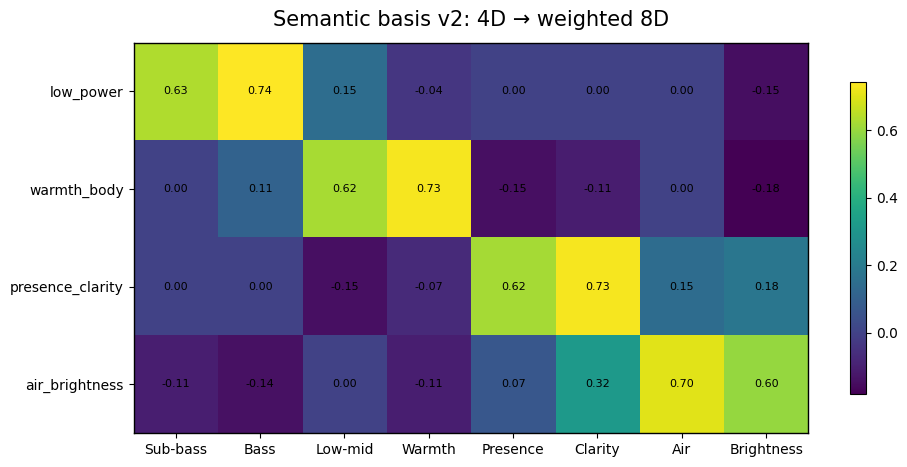

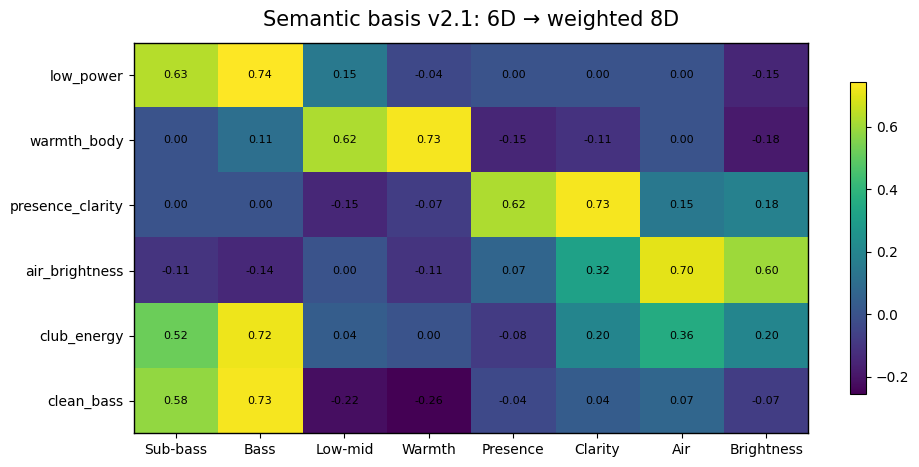

In [2]:
fig, ax = plot_semantic_control_basis_heatmap(
    CONTROL_BASIS_4D_TO_8D,
    CONTROL_NAMES_4D,
    FEATURE_DISPLAY_NAMES_8D_RU,
    title='Semantic basis v2: 4D → weighted 8D',
)
save_figure(fig, FIGURES_DIR / 'v21_basis_heatmap_v2_4d.png')
plt.show()

fig, ax = plot_semantic_control_basis_heatmap(
    CONTROL_BASIS_6D_TO_8D,
    CONTROL_NAMES_6D,
    FEATURE_DISPLAY_NAMES_8D_RU,
    title='Semantic basis v2.1: 6D → weighted 8D',
)
save_figure(fig, FIGURES_DIR / 'v21_basis_heatmap_v21_6d.png')
plt.show()

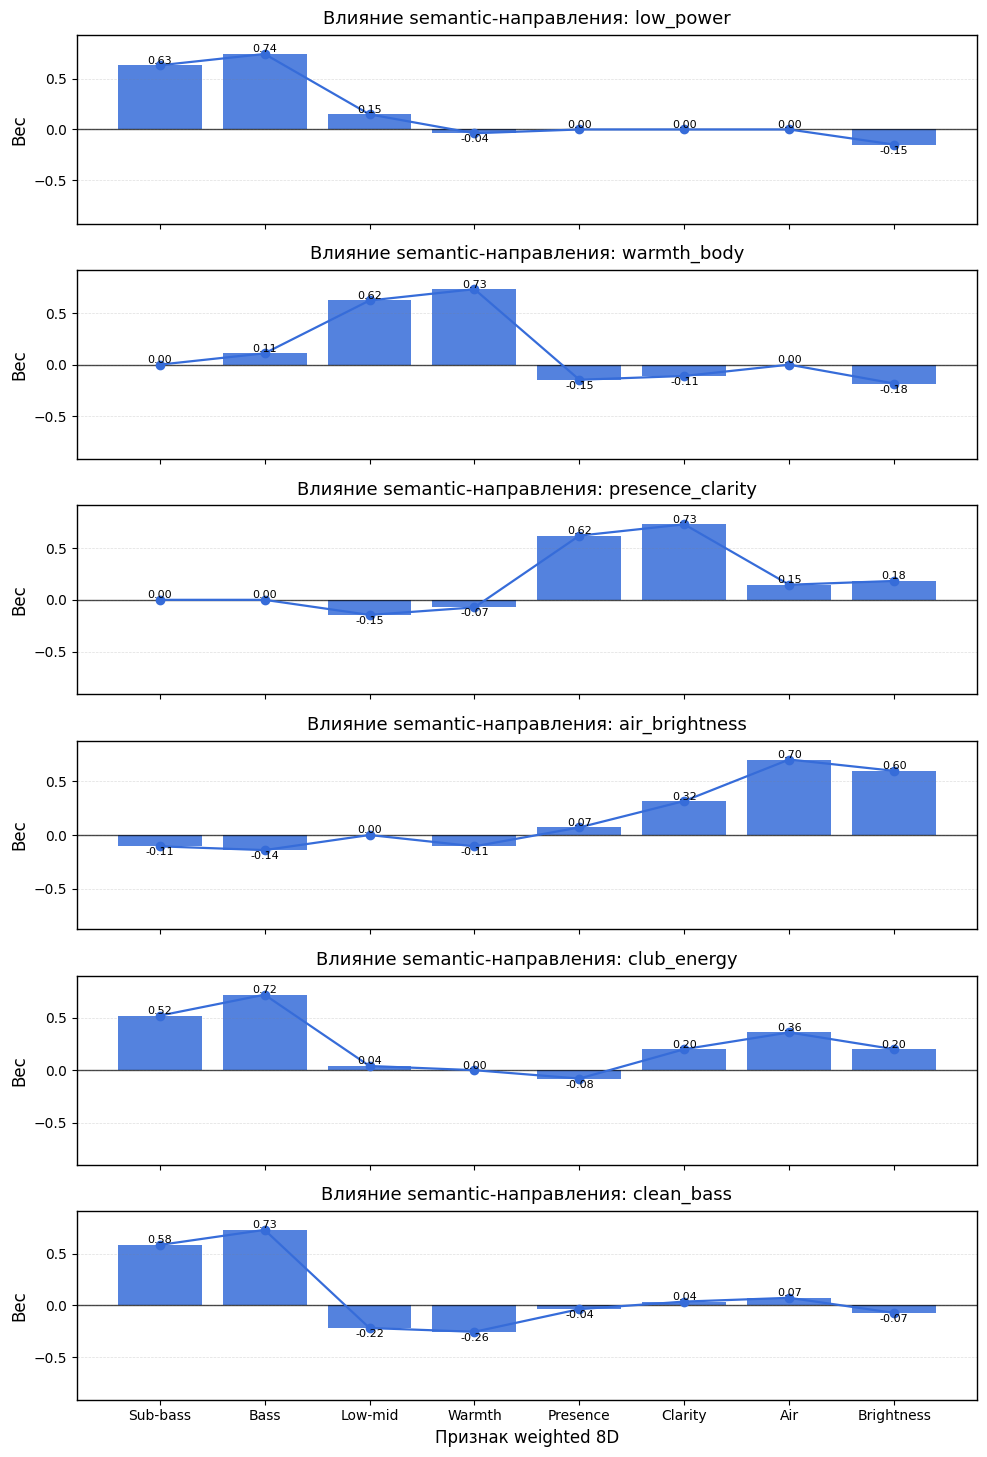

In [3]:
fig, axes = plot_semantic_control_influence(
    CONTROL_BASIS_6D_TO_8D,
    CONTROL_NAMES_6D,
    FEATURE_DISPLAY_NAMES_8D_RU,
    title_prefix='Влияние semantic-направления',
)
save_figure(fig, FIGURES_DIR / 'v21_basis_influence_v21_6d.png')
plt.show()

## 2. Генерация / загрузка fixed synthetic user dataset

Если файл `synthetic_users_v21.csv` уже существует, ноутбук использует его. Если файла нет, он генерируется заново.

В dataset есть четыре режима пользователей:

- `random8d` — произвольные target-векторы в полном weighted 8D;
- `semantic4d` — target лежит в старом semantic 4D-подпространстве;
- `semantic6d` — target лежит в расширенном v2.1 semantic 6D-подпространстве;
- `archetype8d` — реалистичные пользователи как смесь аудио-архетипов с intensity.

In [4]:
if DATASET_PATH.exists():
    dataset = load_synthetic_users_dataset(DATASET_PATH)
    print('Loaded dataset:', DATASET_PATH)
else:
    dataset = generate_synthetic_users_dataset(
        n_per_mode=100,
        seed=42,
        noise_std=0.05,
    )
    save_synthetic_users_dataset(
        dataset=dataset,
        dataset_path=DATASET_PATH,
        metadata_path=DATASET_PATH.with_suffix('.metadata.json'),
        metadata=dataset_metadata(
            dataset_name=DATASET_PATH.stem,
            n_per_mode=100,
            seed=42,
            noise_std=0.05,
            importance_sigma=0.35,
        ),
    )
    print('Generated dataset:', DATASET_PATH)

display(dataset.head())
print(dataset['target_mode'].value_counts())

Loaded dataset: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\datasets\synthetic_users_v21.csv


,user_id,target_mode,noise_std,z_sub_bass,z_bass,z_lowmid,z_warmth,z_presence,z_clarity,z_air,...,mix_warm,mix_bright,mix_v_shape,mix_mid_forward,mix_soft_dark,mix_detail_focused,mix_basshead,mix_extreme_vshape,mix_club_curve,mix_sparkle_lover
0,0,random8d,0.05,0.243774,-0.831987,0.600361,0.752452,-1.560828,-1.041744,0.102272,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,random8d,0.05,0.295001,-0.767106,0.702760,-0.039941,-0.147890,-0.544744,0.978033,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,random8d,0.05,-0.409794,-0.651018,0.492784,0.903178,-0.091158,-0.672125,-0.659585,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,random8d,0.05,0.543131,0.054063,0.231296,0.505031,-1.165725,-0.255737,-0.376298,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,random8d,0.05,0.568981,0.634678,-0.278980,-0.369881,0.686381,-0.153043,-1.020549,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


target_mode
random8d       100
semantic4d     100
semantic6d     100
archetype8d    100
Name: count, dtype: int64


## 3. Batch-сравнение стратегий

Сравниваем:

- `random` — случайное многомерное направление;
- `uncertainty_axis` — одна неопределённая 8D-ось;
- `semantic_control` — старая semantic basis v2, 4 направления;
- `semantic_control_v21` — новая semantic basis v2.1, 6 направлений;
- `hybrid` — смесь random + semantic 4D + uncertainty-axis;
- `hybrid_v21` — смесь random + semantic 6D + uncertainty-axis.

In [5]:
STRATEGIES = [
    'random',
    'uncertainty_axis',
    'semantic_control',
    'semantic_control_v21',
    'hybrid',
    'hybrid_v21',
]

sessions_df, curves = run_batch_on_dataset(
    dataset=dataset,
    strategies=STRATEGIES,
    n_steps=25,
    step_scale=0.6,
    lr=0.25,
)

strategy_summary = summarize_by_strategy(sessions_df)
win_rates = win_rates_vs_baseline(sessions_df, baseline='random')

save_batch_outputs(
    sessions=sessions_df,
    strategy_summary=strategy_summary,
    win_rates=win_rates,
    output_dir=METRICS_DIR,
    prefix='notebook_v21_semantic_compare',
)

display(strategy_summary)
display(win_rates)

,target_mode,strategy,users,mean_initial_distance,mean_final_distance,std_final_distance,mean_best_distance,mean_mean_distance,mean_improvement_pct,std_improvement_pct
4,archetype8d,semantic_control_v21,100,1.102635,0.476987,0.164772,0.322239,0.616510,44.705813,38.626852
3,archetype8d,semantic_control,100,1.102635,0.514512,0.240657,0.370673,0.663550,41.225847,39.868696
5,archetype8d,uncertainty_axis,100,1.102635,0.533740,0.259131,0.443866,0.760355,41.021812,35.416559
1,archetype8d,hybrid_v21,100,1.102635,0.545030,0.170712,0.421176,0.720359,36.142067,43.176286
0,archetype8d,hybrid,100,1.102635,0.545333,0.214747,0.414104,0.728954,37.915795,39.970156
2,archetype8d,random,100,1.102635,0.567765,0.214612,0.472785,0.770912,35.841547,41.039317
11,random8d,uncertainty_axis,100,2.212002,0.985761,0.415946,0.960684,1.546811,56.663880,11.459939
8,random8d,random,100,2.212002,0.996708,0.402072,0.979050,1.572826,55.800212,11.632861
6,random8d,hybrid,100,2.212002,1.014066,0.437097,0.984504,1.550532,55.277025,12.222053
7,random8d,hybrid_v21,100,2.212002,1.063145,0.422485,1.037094,1.572542,52.716079,11.436396


,target_mode,strategy,baseline,win_rate_final_distance,win_rate_best_distance
0,archetype8d,hybrid,random,0.52,0.63
1,archetype8d,hybrid_v21,random,0.55,0.57
2,archetype8d,semantic_control,random,0.60,0.74
3,archetype8d,semantic_control_v21,random,0.65,0.79
4,archetype8d,uncertainty_axis,random,0.61,0.58
5,random8d,hybrid,random,0.49,0.49
6,random8d,hybrid_v21,random,0.48,0.47
7,random8d,semantic_control,random,0.11,0.11
8,random8d,semantic_control_v21,random,0.08,0.08
9,random8d,uncertainty_axis,random,0.53,0.51


## 4. Средняя сходимость по режимам пользователей

Графики показывают среднее расстояние до скрытого target в течение A/B-сессии. Чем ниже кривая, тем быстрее стратегия приближается к скрытому preference target.

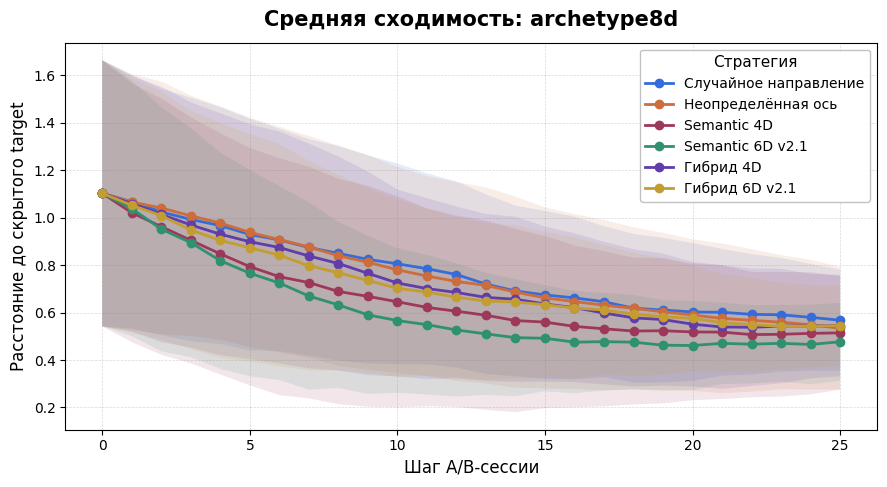

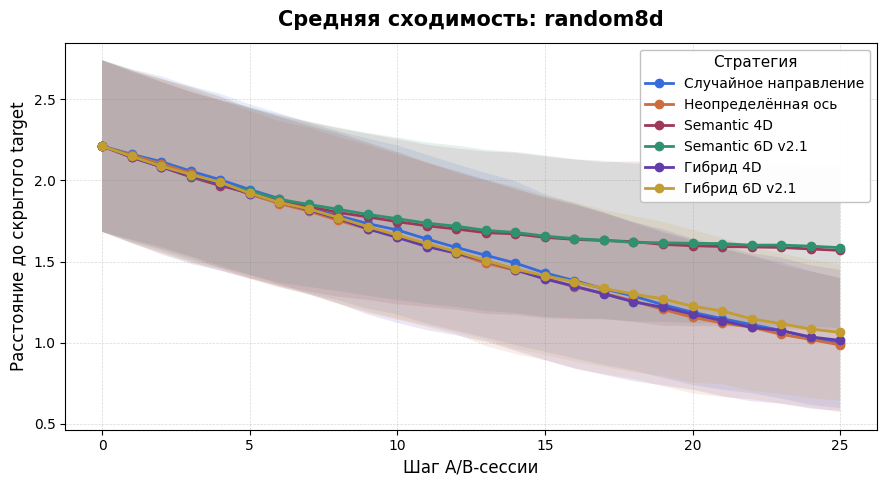

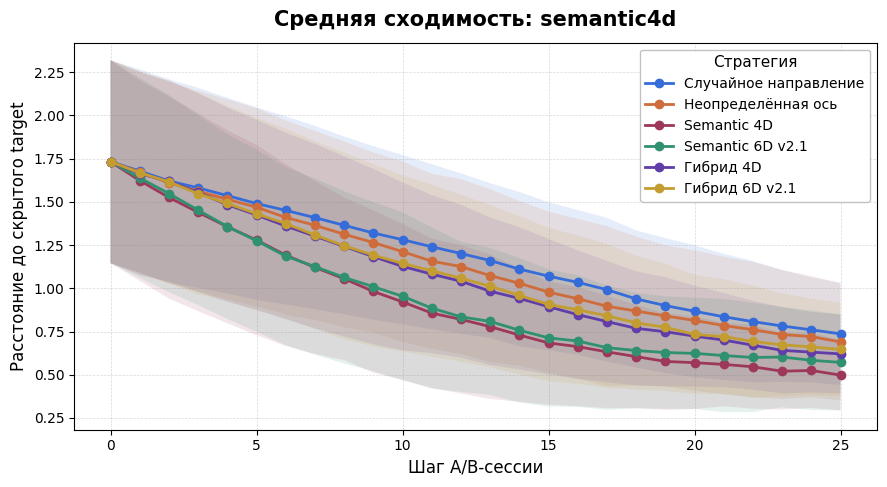

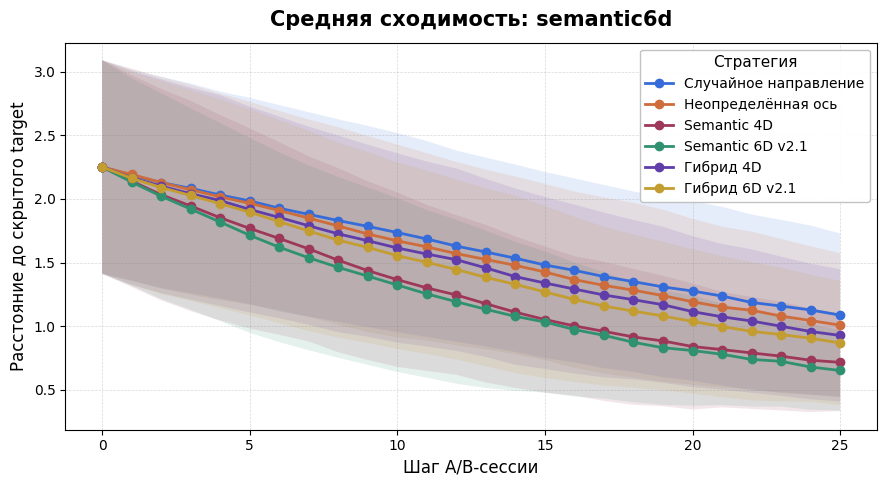

In [6]:
for target_mode in sorted(curves.keys()):
    fig, ax = plot_average_convergence_by_strategy(
        curves[target_mode],
        strategy_display_names=STRATEGY_DISPLAY_NAMES_RU,
        title=f'Средняя сходимость: {target_mode}',
    )
    save_figure(fig, FIGURES_DIR / f'v21_convergence_{target_mode}.png')
    plt.show()

## 5. Анализ по target mode, intensity и архетипам

In [7]:
sessions_with_meta = merge_sessions_with_user_metadata(sessions_df, dataset)
sessions_with_meta.to_csv(METRICS_DIR / 'notebook_v21_semantic_compare_sessions_with_meta.csv', index=False)

target_mode_summary = summarize_by_group(sessions_with_meta, ['target_mode'])
target_mode_winners = winners_by_group(target_mode_summary, ['target_mode'])
target_mode_win_rates = win_rates_vs_baseline_by_group(sessions_with_meta, ['target_mode'])

for name, df in [
    ('notebook_v21_target_mode_group_summary.csv', target_mode_summary),
    ('notebook_v21_target_mode_winners.csv', target_mode_winners),
    ('notebook_v21_target_mode_win_rates.csv', target_mode_win_rates),
]:
    df.to_csv(METRICS_DIR / name, index=False)

display(target_mode_summary)
display(target_mode_winners)
display(target_mode_win_rates)

,target_mode,strategy,users,mean_initial_distance,mean_final_distance,std_final_distance,mean_best_distance,mean_mean_distance,mean_improvement_pct,std_improvement_pct
4,archetype8d,semantic_control_v21,100,1.102635,0.476987,0.164772,0.322239,0.616510,44.705813,38.626852
3,archetype8d,semantic_control,100,1.102635,0.514512,0.240657,0.370673,0.663550,41.225847,39.868696
5,archetype8d,uncertainty_axis,100,1.102635,0.533740,0.259131,0.443866,0.760355,41.021812,35.416559
1,archetype8d,hybrid_v21,100,1.102635,0.545030,0.170712,0.421176,0.720359,36.142067,43.176286
0,archetype8d,hybrid,100,1.102635,0.545333,0.214747,0.414104,0.728954,37.915795,39.970156
2,archetype8d,random,100,1.102635,0.567765,0.214612,0.472785,0.770912,35.841547,41.039317
11,random8d,uncertainty_axis,100,2.212002,0.985761,0.415946,0.960684,1.546811,56.663880,11.459939
8,random8d,random,100,2.212002,0.996708,0.402072,0.979050,1.572826,55.800212,11.632861
6,random8d,hybrid,100,2.212002,1.014066,0.437097,0.984504,1.550532,55.277025,12.222053
7,random8d,hybrid_v21,100,2.212002,1.063145,0.422485,1.037094,1.572542,52.716079,11.436396


,target_mode,winner_strategy,users,winner_mean_final_distance
0,archetype8d,semantic_control_v21,100,0.476987
1,semantic4d,semantic_control,100,0.497815
2,semantic6d,semantic_control_v21,100,0.652402
3,random8d,uncertainty_axis,100,0.985761


,target_mode,strategy,baseline,win_rate_final_distance,n_users
0,archetype8d,uncertainty_axis,random,0.61,100
1,archetype8d,semantic_control,random,0.60,100
2,archetype8d,semantic_control_v21,random,0.65,100
3,archetype8d,hybrid,random,0.52,100
4,archetype8d,hybrid_v21,random,0.55,100
5,random8d,uncertainty_axis,random,0.53,100
6,random8d,semantic_control,random,0.11,100
7,random8d,semantic_control_v21,random,0.08,100
8,random8d,hybrid,random,0.49,100
9,random8d,hybrid_v21,random,0.48,100


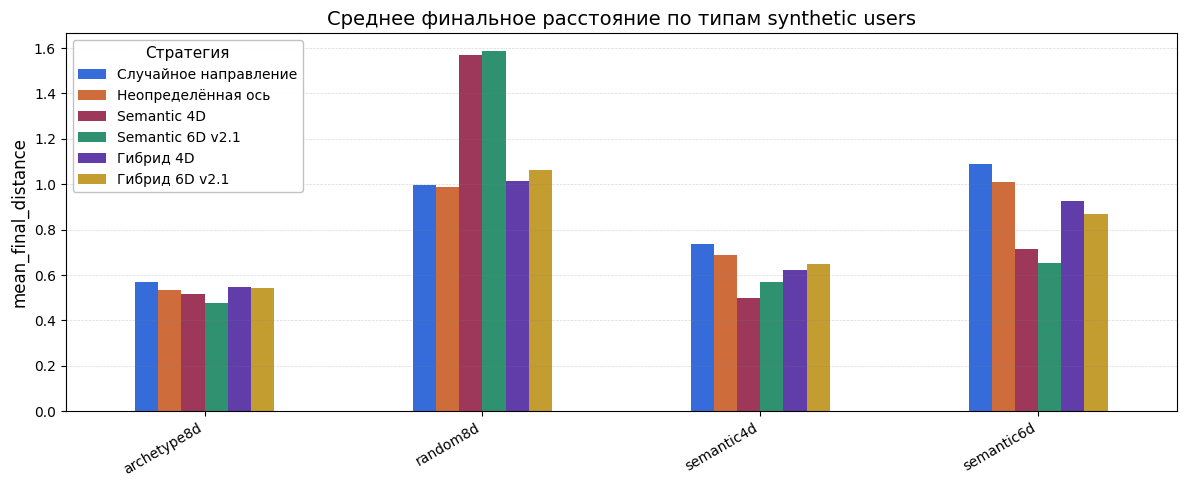

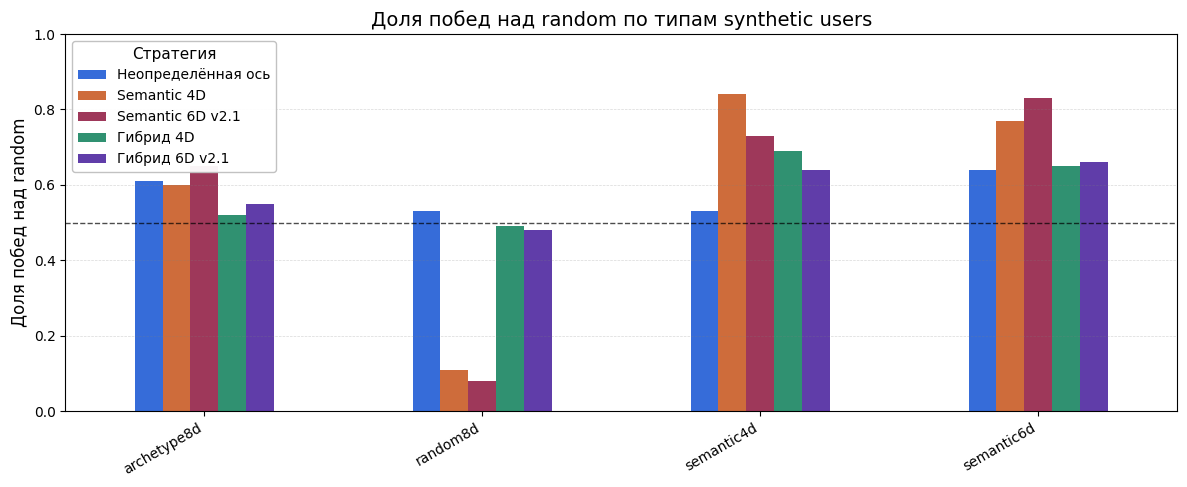

In [8]:
fig, ax = plot_group_metric_bars(
    target_mode_summary,
    group_col='target_mode',
    title='Среднее финальное расстояние по типам synthetic users',
    figsize=(12, 5),
)
save_figure(fig, FIGURES_DIR / 'v21_final_distance_by_target_mode.png')
plt.show()

fig, ax = plot_win_rate_bars(
    target_mode_win_rates,
    group_col='target_mode',
    title='Доля побед над random по типам synthetic users',
    figsize=(12, 5),
)
save_figure(fig, FIGURES_DIR / 'v21_win_rate_by_target_mode.png')
plt.show()

In [9]:
archetype_sessions = sessions_with_meta[sessions_with_meta['target_mode'] == 'archetype8d'].copy()

intensity_summary = summarize_by_group(archetype_sessions, ['intensity_label'])
intensity_win_rates = win_rates_vs_baseline_by_group(archetype_sessions, ['intensity_label'])

main_archetype_summary = summarize_by_group(archetype_sessions, ['main_archetype'])
main_archetype_win_rates = win_rates_vs_baseline_by_group(archetype_sessions, ['main_archetype'])

intensity_summary.to_csv(METRICS_DIR / 'notebook_v21_intensity_group_summary.csv', index=False)
intensity_win_rates.to_csv(METRICS_DIR / 'notebook_v21_intensity_win_rates.csv', index=False)
main_archetype_summary.to_csv(METRICS_DIR / 'notebook_v21_main_archetype_group_summary.csv', index=False)
main_archetype_win_rates.to_csv(METRICS_DIR / 'notebook_v21_main_archetype_win_rates.csv', index=False)

display(intensity_summary)
display(intensity_win_rates)
display(main_archetype_summary)
display(main_archetype_win_rates)

,intensity_label,strategy,users,mean_initial_distance,mean_final_distance,std_final_distance,mean_best_distance,mean_mean_distance,mean_improvement_pct,std_improvement_pct
4,extreme,semantic_control_v21,16,1.382814,0.547728,0.250569,0.455746,0.825583,51.460459,23.859111
2,extreme,random,16,1.382814,0.627439,0.327190,0.546072,0.954679,45.520765,25.138565
3,extreme,semantic_control,16,1.382814,0.636339,0.393680,0.505712,0.877895,43.755640,31.489379
0,extreme,hybrid,16,1.382814,0.637314,0.403643,0.528855,0.950728,45.058718,25.663243
1,extreme,hybrid_v21,16,1.382814,0.665535,0.263291,0.544381,0.937994,38.378069,31.608590
5,extreme,uncertainty_axis,16,1.382814,0.719503,0.444891,0.609143,0.987428,39.878168,25.301019
10,mild,semantic_control_v21,15,0.633372,0.426521,0.175027,0.255606,0.446882,16.186087,52.292898
8,mild,random,15,0.633372,0.443981,0.124184,0.306414,0.506998,7.349563,65.705452
11,mild,uncertainty_axis,15,0.633372,0.453921,0.115475,0.338716,0.529866,12.171314,48.378003
9,mild,semantic_control,15,0.633372,0.478629,0.173618,0.292474,0.470025,9.954108,42.642492


,intensity_label,strategy,baseline,win_rate_final_distance,n_users
0,extreme,uncertainty_axis,random,0.312500,16
1,extreme,semantic_control,random,0.500000,16
2,extreme,semantic_control_v21,random,0.562500,16
3,extreme,hybrid,random,0.562500,16
4,extreme,hybrid_v21,random,0.375000,16
5,mild,uncertainty_axis,random,0.466667,15
6,mild,semantic_control,random,0.333333,15
7,mild,semantic_control_v21,random,0.666667,15
8,mild,hybrid,random,0.400000,15
9,mild,hybrid_v21,random,0.400000,15


,main_archetype,strategy,users,mean_initial_distance,mean_final_distance,std_final_distance,mean_best_distance,mean_mean_distance,mean_improvement_pct,std_improvement_pct
2,bass_lover,random,7,1.077502,0.397822,0.135922,0.357954,0.691390,58.330740,29.236898
5,bass_lover,uncertainty_axis,7,1.077502,0.454155,0.144945,0.414871,0.706812,55.433790,16.929935
0,bass_lover,hybrid,7,1.077502,0.496883,0.125163,0.403396,0.719282,51.036181,15.099225
4,bass_lover,semantic_control_v21,7,1.077502,0.518051,0.135142,0.285219,0.554388,49.620014,13.373504
3,bass_lover,semantic_control,7,1.077502,0.518405,0.161698,0.297433,0.604838,44.960977,32.400947
...,...,...,...,...,...,...,...,...,...,...
70,warm,semantic_control_v21,14,1.000837,0.429846,0.083698,0.296502,0.596797,54.575320,10.936146
71,warm,uncertainty_axis,14,1.000837,0.431094,0.082357,0.344898,0.649550,53.242469,16.389733
67,warm,hybrid_v21,14,1.000837,0.502570,0.112139,0.392351,0.654361,46.397168,17.740668
66,warm,hybrid,14,1.000837,0.514475,0.089578,0.368150,0.634252,43.982584,19.099111


,main_archetype,strategy,baseline,win_rate_final_distance,n_users
0,bass_lover,uncertainty_axis,random,0.285714,7
1,bass_lover,semantic_control,random,0.285714,7
2,bass_lover,semantic_control_v21,random,0.142857,7
3,bass_lover,hybrid,random,0.285714,7
4,bass_lover,hybrid_v21,random,0.428571,7
5,basshead,uncertainty_axis,random,0.363636,11
6,basshead,semantic_control,random,0.636364,11
7,basshead,semantic_control_v21,random,0.545455,11
8,basshead,hybrid,random,0.272727,11
9,basshead,hybrid_v21,random,0.545455,11


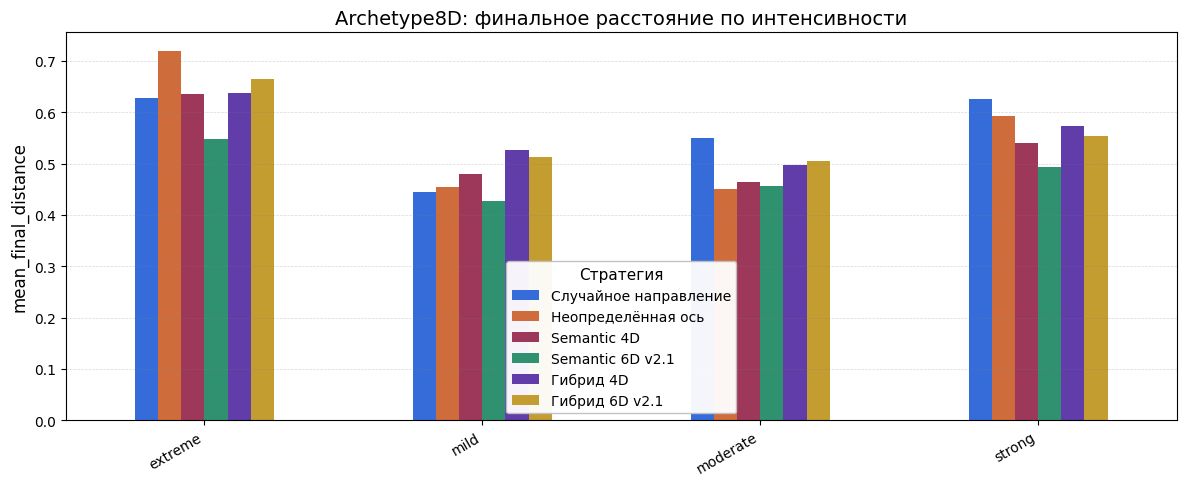

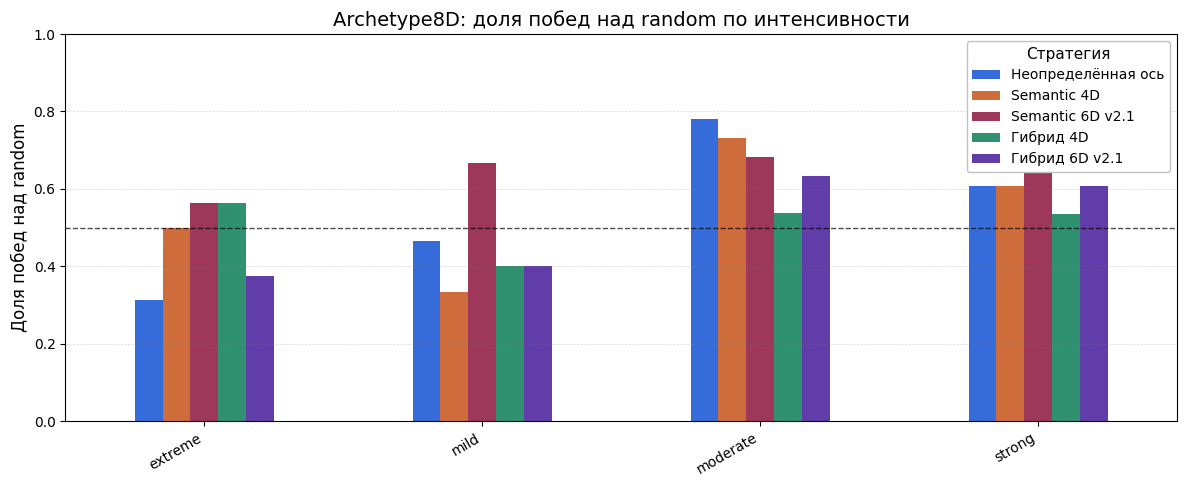

In [10]:
fig, ax = plot_group_metric_bars(
    intensity_summary,
    group_col='intensity_label',
    title='Archetype8D: финальное расстояние по интенсивности',
    figsize=(12, 5),
)
save_figure(fig, FIGURES_DIR / 'v21_archetype_final_distance_by_intensity.png')
plt.show()

fig, ax = plot_win_rate_bars(
    intensity_win_rates,
    group_col='intensity_label',
    title='Archetype8D: доля побед над random по интенсивности',
    figsize=(12, 5),
)
save_figure(fig, FIGURES_DIR / 'v21_archetype_win_rate_by_intensity.png')
plt.show()

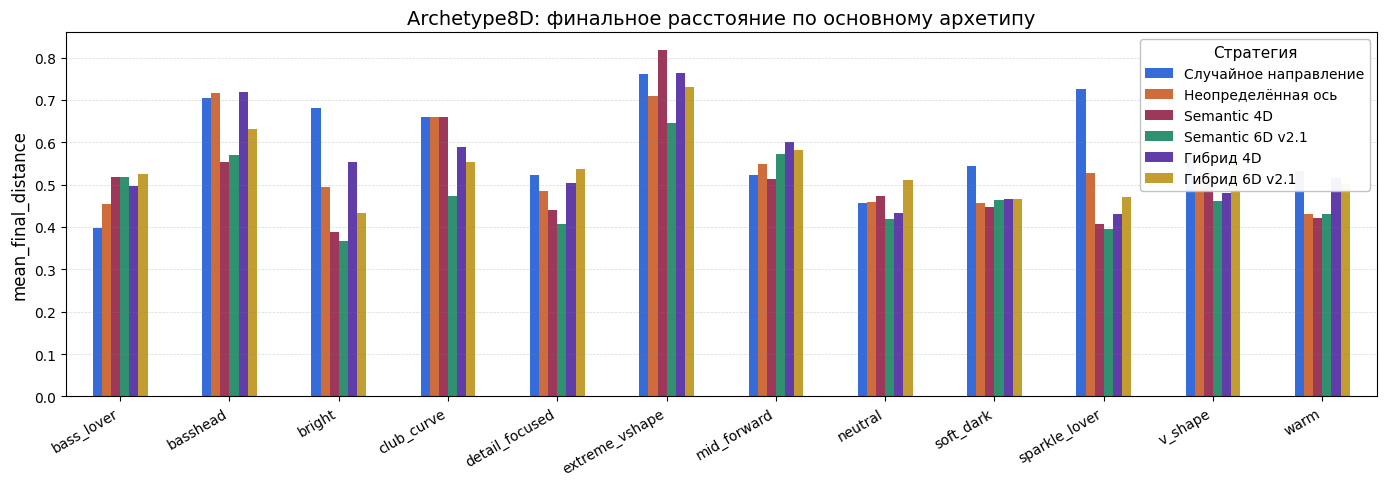

In [11]:
fig, ax = plot_group_metric_bars(
    main_archetype_summary,
    group_col='main_archetype',
    title='Archetype8D: финальное расстояние по основному архетипу',
    figsize=(14, 5),
)
save_figure(fig, FIGURES_DIR / 'v21_archetype_final_distance_by_main_archetype.png')
plt.show()

## 8. Сравнение semantic basis v2 и v2.1 по архетипам

Ниже считается, где расширенная semantic basis v2.1 (`semantic_control_v21`) улучшает исходную 4D basis v2 (`semantic_control`). Для distance-метрик положительное значение improvement означает, что v2.1 дала меньшее расстояние до скрытого target.

In [12]:
# Сравнение v2 и v2.1 по основным archetype8d-профилям
v21_vs_v2_by_archetype = compare_two_strategies_by_group(
    main_archetype_summary,
    group_col='main_archetype',
    old_strategy='semantic_control',
    new_strategy='semantic_control_v21',
    metric='mean_final_distance',
)

v21_vs_v2_win_rates_by_archetype = win_rate_between_strategies_by_group(
    archetype_sessions,
    group_cols=['main_archetype'],
    strategy_a='semantic_control_v21',
    strategy_b='semantic_control',
    metric='final_distance',
)

v21_vs_v2_by_archetype.to_csv(
    METRICS_DIR / 'notebook_v21_v21_vs_v2_by_archetype.csv',
    index=False,
)
v21_vs_v2_win_rates_by_archetype.to_csv(
    METRICS_DIR / 'notebook_v21_v21_vs_v2_win_rates_by_archetype.csv',
    index=False,
)

display(v21_vs_v2_by_archetype)
display(v21_vs_v2_win_rates_by_archetype)

,main_archetype,semantic_control_mean_final_distance,semantic_control_v21_mean_final_distance,improvement_abs,improvement_pct,winner
0,club_curve,0.659089,0.472399,0.186690,28.325424,semantic_control_v21
1,extreme_vshape,0.818532,0.644648,0.173885,21.243464,semantic_control_v21
2,v_shape,0.520322,0.461212,0.059110,11.360240,semantic_control_v21
3,neutral,0.473301,0.418053,0.055249,11.673045,semantic_control_v21
4,detail_focused,0.439447,0.406992,0.032455,7.385378,semantic_control_v21
5,bright,0.387364,0.365925,0.021439,5.534687,semantic_control_v21
6,sparkle_lover,0.406274,0.395240,0.011034,2.715974,semantic_control_v21
7,bass_lover,0.518405,0.518051,0.000354,0.068197,semantic_control_v21
8,warm,0.420200,0.429846,-0.009646,-2.295502,semantic_control
9,basshead,0.554447,0.569370,-0.014923,-2.691510,semantic_control


,main_archetype,strategy_a,strategy_b,win_rate_final_distance,n_users
0,bass_lover,semantic_control_v21,semantic_control,0.428571,7
1,basshead,semantic_control_v21,semantic_control,0.363636,11
2,bright,semantic_control_v21,semantic_control,0.666667,3
3,club_curve,semantic_control_v21,semantic_control,0.727273,11
4,detail_focused,semantic_control_v21,semantic_control,0.800000,10
5,extreme_vshape,semantic_control_v21,semantic_control,0.666667,6
6,mid_forward,semantic_control_v21,semantic_control,0.285714,7
7,neutral,semantic_control_v21,semantic_control,0.466667,15
8,soft_dark,semantic_control_v21,semantic_control,0.444444,9
9,sparkle_lover,semantic_control_v21,semantic_control,0.500000,2


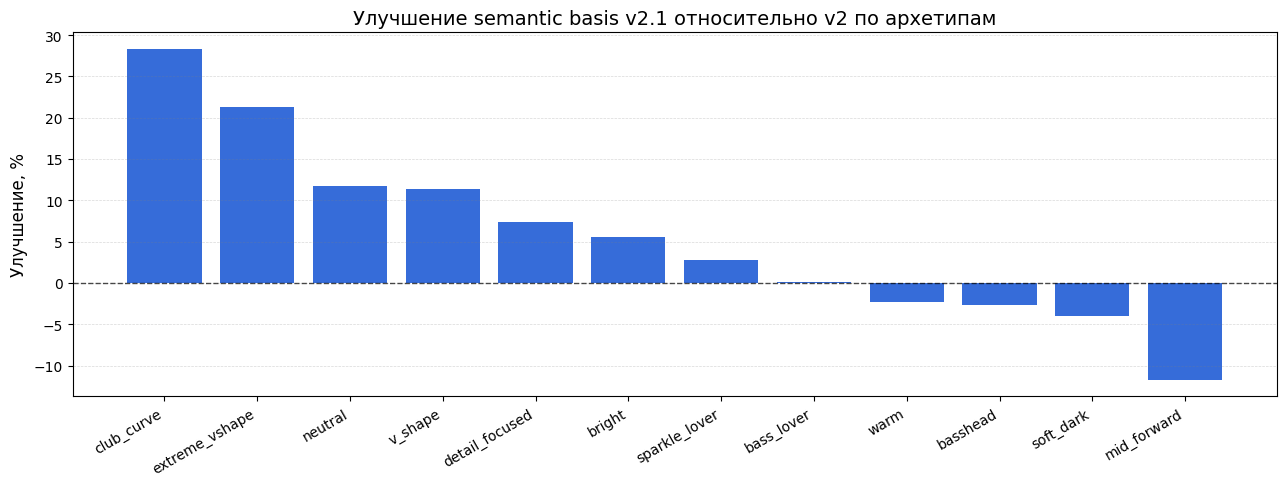

In [13]:
fig, ax = plot_strategy_improvement_bars(
    v21_vs_v2_by_archetype,
    group_col='main_archetype',
    value_col='improvement_pct',
    title='Улучшение semantic basis v2.1 относительно v2 по архетипам',
    figsize=(13, 5),
)
save_figure(fig, FIGURES_DIR / 'v21_improvement_vs_v2_by_archetype.png')
plt.show()

Расширение semantic basis с 4D до 6D улучшило качество персонализации на реалистичном `archetype8d`-наборе пользователей. Наиболее заметный выигрыш получен для архетипов `club_curve` и `extreme_vshape`, что подтверждает полезность добавленных направлений `club_energy` и `clean_bass`. При этом старая 4D semantic basis остаётся более подходящей для некоторых warm/dark/mid-forward профилей, что показывает зависимость эффективности semantic controls от структуры пользовательского target.

В целом `semantic_control_v21` можно рассматривать как более универсальную semantic-стратегию для реалистичных пользователей, тогда как `semantic_control` лучше соответствует исходному 4D semantic-подпространству. Для произвольных `random8d` targets semantic-подход ожидаемо проигрывает более общим стратегиям, так как ограничивает пространство поиска.